# Effect of contact definition on contact pressure metrics on each surface (mc1, tpm)
 - master slave differences
 - computation differences
    - Area weighted average vs non-zero nodes / CAREA

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from phd_helpers.AbaqusPostprocessing import inp2pv, get_history_path, get_field_path, get_field_df, add_field_to_mesh
from phd_helpers.experiments import build_sensor_mesh, get_sensor_loc, project_sensor_new

In [13]:
def get_step_ids(inp_file):
    history_files = list(inp_file.parent.glob('resultCSVs/history*.csv'))
    step_ids = np.sort(np.unique([int(x.with_suffix('').name.replace('history_step-', '')) for x in history_files]))
    return step_ids

def fea_mets_from_mesh(mesh):
    return {
        'CA': mesh.field_data['CA'][0],
        'P_max': mesh.field_data['P_max'][0],
        'P_avg': mesh.field_data['P_avg'][0],
        'P_avg_weighted': mesh.field_data['P_avg_weighted'][0],
        'loc_Pmax': mesh.field_data['loc_Pmax'],
    }

def find_boundary_cells(a):
    """
    input: NxM array of cells
    Returns: NxM (1, 0) array of non-zero cells that border a zero"""
    a = np.asarray(a)
    m = a > 0
    out = np.zeros(a.shape, dtype=bool)

    out[1:, :]  |= m[1:, :]  & (a[:-1, :] == 0)
    out[:-1, :] |= m[:-1, :] & (a[1:, :] == 0)
    out[:, 1:]  |= m[:, 1:]  & (a[:, :-1] == 0)
    out[:, :-1] |= m[:, :-1] & (a[:, 1:] == 0)

    return out

def compute_img_metrics(img, sensel_area=1.6129):

    CA = len(img[img>0]) * sensel_area
    # CA error - between 25% and 125% of the area of the boundary cells 
    # - plenty of cases that could exceed these limits but still reasonable limits I think...
    # - Given the nature of the contacting surfaces, it would be impossible for every boundary cell to be an edge case 
    # - so error bars based on those would give unreasonably wide range
    CA_e_low = find_boundary_cells(img).sum() * sensel_area * 0.75 # lower bound error bar for CA
    CA_e_high = find_boundary_cells(img).sum() * sensel_area * 0.25 # upper bound error bar for CA
    
    P_max = img.max()
    P_avg = img[img>0].mean()
    loc_Pmax = np.array(np.where(img==img.max())).ravel() # idx - (i, j)

    return {
        'CA': CA,
        'CA_e_low': CA_e_low,
        'CA_e_high': CA_e_high,
        'P_max': P_max,
        'P_avg': P_avg,
        'loc_Pmax': loc_Pmax
    }

def compute_CA_overlap(img_fea, img_tek):
    mask_fea = (img_fea > 0)
    mask_tek = (img_tek > 0)
    CA_mean = (mask_fea.sum() + mask_tek.sum()) / 2
    CA_overlap = (mask_fea & mask_tek).sum()

    return 100-(100 * (CA_mean - CA_overlap) / CA_mean)

In [14]:
def compute_Pavg(mesh):
    """Converts CPRESS to cell data and computes area weighted average pressure"""
    tet_surf = mesh.extract_cells_by_type(10).extract_surface(algorithm=None)
    P = tet_surf.point_data_to_cell_data().cell_data['CPRESS'] 
        # CPRESS comes as point data
        # this assigns to each elements CPRESS value, the average of the CPRESS of the 3 points of the element
        # Edge case: elements has point CPRESS = [0, 0, 1.5], element given CPRESS = 0.5, but entire area considered in contact for avg
        # This slightly overestimates area and therefore reduces average pressure
    A = tet_surf.compute_cell_sizes()["Area"]
    mask = P > 0

    return np.sum(P[mask] * A[mask]) / np.sum(A[mask])

def get_fe_data(csv_dir, Fs, bone='tpm'):
    inp_file = list(csv_dir.parent.glob('*.inp'))[0]

    force_steps = get_step_ids(inp_file)[1:]

    frame = -1 # final frame of each step
    field_metrics = ["CPRESS", "U"]


    fea_data = {} # {F1: {'tpm':mesh1, 'mc1':mesh1}, ...} - each mesh contains all fea data
    for step, F in zip(force_steps, Fs):
        #meshes = meshes_orig.copy()
        meshes = inp2pv(inp_file)
        for bone, mesh in meshes.items():
            instance = f"{bone.upper()}_INST"
            
            # Field data
            for metric in field_metrics:
                field_path = get_field_path(csv_dir, metric, step, frame, instance)
                field_df = get_field_df(field_path)
                add_field_to_mesh(mesh, field_df)

            # History data
            history_data = pd.read_csv(get_history_path(csv_dir, step))
            # F
            #RF_data = history_data[history_data['historyOutputKey']=='RF1']
            #RF = np.abs(RF_data['value'].iloc[frame])
            # A
            CAREA_data = history_data[history_data['historyOutputDescription']=='Total area in contact']
            CA = CAREA_data['value'].iloc[frame]

            mesh.field_data['RF'] = F
            mesh.field_data['CA'] = CA

            
            #Summary data
            mesh.field_data['P_max'] = mesh['CPRESS'].max()
            mesh.field_data['P_avg_weighted'] = compute_Pavg(mesh)
            mesh.field_data['P_avg'] = np.mean(mesh['CPRESS'][mesh['CPRESS']>0])
            mesh.field_data['loc_Pmax'] = np.array(mesh.points[np.argmax(mesh['CPRESS'])])

        fea_data[F] = meshes

    return fea_data

def get_fe_grid_data(fea_data, Fs, tek_data, bone='tpm'):

    fea_grid_data = {}
    for F in Fs:

        surf = fea_data[F][bone].extract_surface(algorithm=None)
        mesh = surf.extract_cells(surf[f'{bone}_CART_SURF']==1).extract_surface(algorithm=None)

        sensor_loc = get_sensor_loc(fea_data[F]['mc1'], guide_wall_z=10, sensor_offset_z=-2, sensor_size=13.97) # skinny guide ledge
        sensor = build_sensor_mesh(sensor_loc, normal=(1, 0, 0), ncells=11, size=13.97)
        
        fea_grid_new = project_sensor_new(
            mesh=mesh,
            sensor=sensor,
            sensor_vals=tek_data[F],
            data_loc="cells",
            downscale_fea=True,
            return_fea_grid=True,
            active_sensel_width=0.635,  # use your model units
            pressure_name="CPRESS",
        )
        
        
        fea_grid_data[F] = fea_grid_new

    return fea_grid_data

In [25]:
Fs = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150] # N

# surface-to-surface contact tpm primary
tpm_exp_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study3_35T4d5_Fsteps/inpFiles/14548R/inp/35T-neutral-00/resultCSVs')
# surface-to-surface contact mc1 primary
mc1_exp_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study3_mc1Main/inpFiles/14548R/inp/35T-neutral-00/resultCSVs')
# general contact (tpm listed first - does it matter?)
gen_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/study3_mc1Main/inpFiles/14548R/inp/35T-neutral-01/resultCSVs')

tpm_exp = get_fe_data(tpm_exp_path, Fs)
mc1_exp = get_fe_data(mc1_exp_path, Fs)
gen = get_fe_data(gen_path, Fs)

fe_data = [tpm_exp, mc1_exp, gen]
names = ['tpm_primary', 'mc1_primary', 'general']


# TPM vs MC1 for surface-to-surface tpm primary
 - All pretty much the same except for non-area-weighted average pressure
    - non-area-weighed average are triangle transparent points
 - Should be using area weighted average pressure

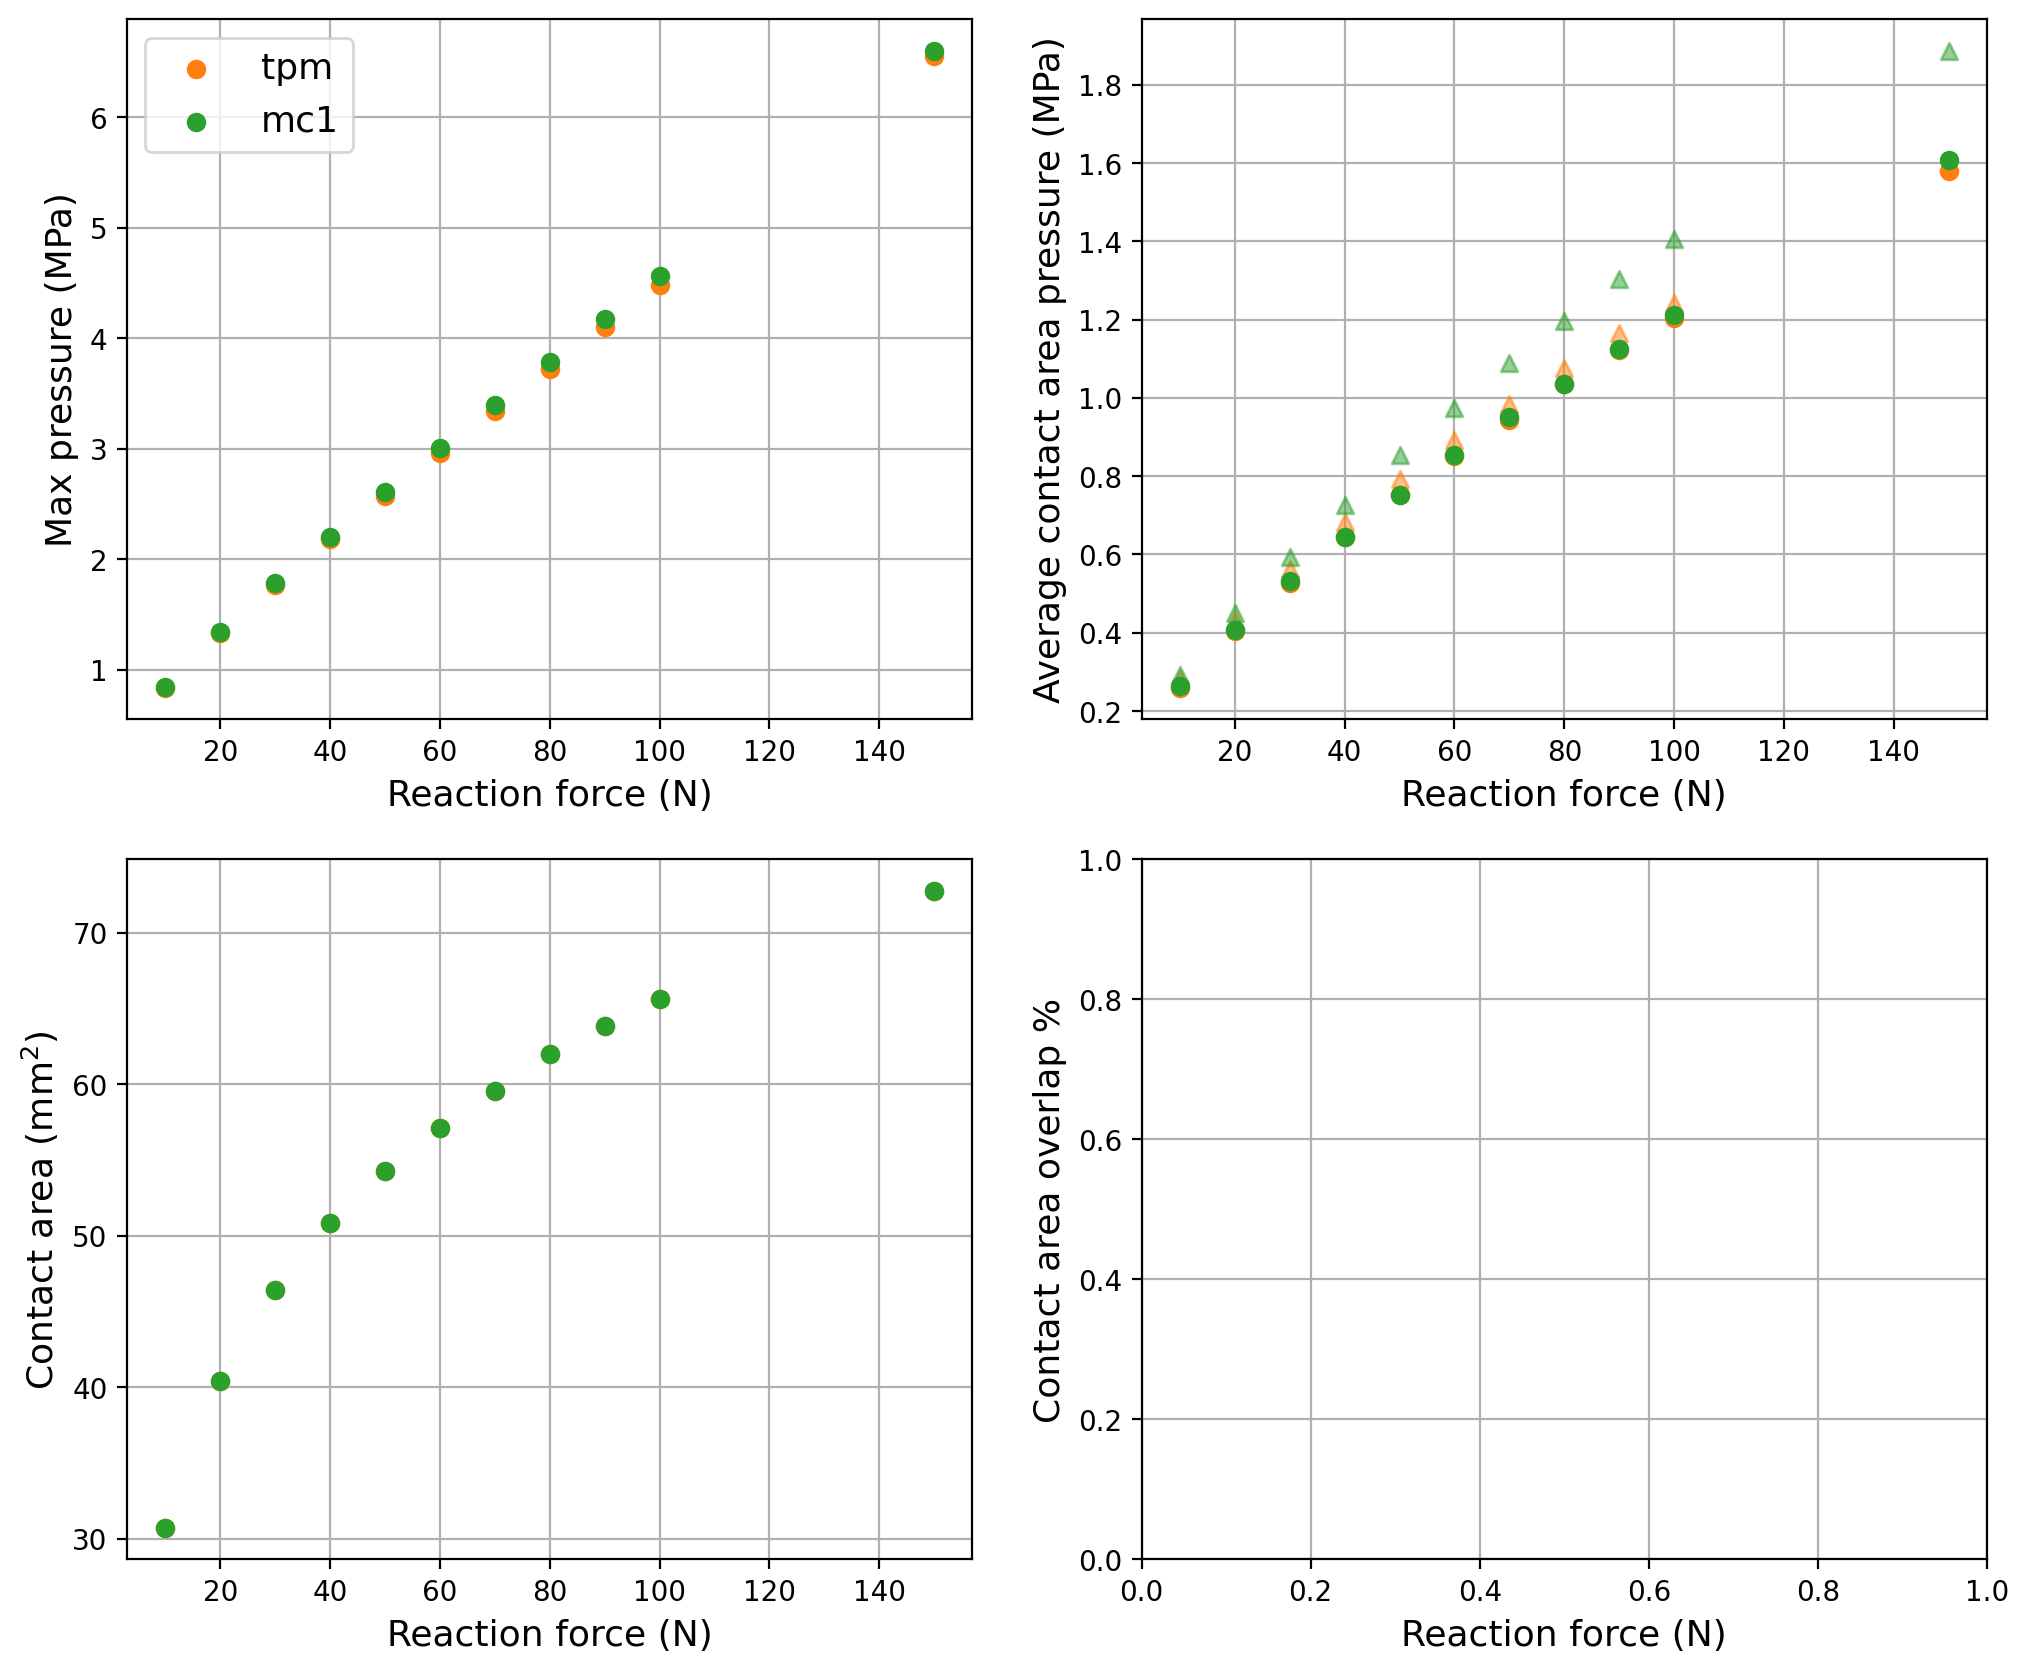

In [23]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13

cs = ['C1', 'C2']

for i, fea_data in enumerate(fe_data):
    for j, bone in enumerate(['tpm', 'mc1']):
        for F in fea_data:
            fea_mets = fea_mets_from_mesh(fea_data[F][bone])

            label_fe = bone if F==10 else None
            ax[0].scatter(F, fea_mets['P_max'], c=cs[j], label=label_fe, zorder=2)
            ax[1].scatter(F, fea_mets['P_avg'], c=cs[j], marker='^', zorder=2, alpha=0.5)
            ax[1].scatter(F, fea_mets['P_avg_weighted'], c=cs[j], zorder=2)
            ax[2].scatter(F, fea_mets['CA'], c=cs[j], zorder=2)



ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
#ax[3].legend(fontsize=fs)
plt.show()

# Surface-to-surface vs surface-to-surface vs general
 - Makes no difference
 - Only non-area-weighted average pressure makes difference

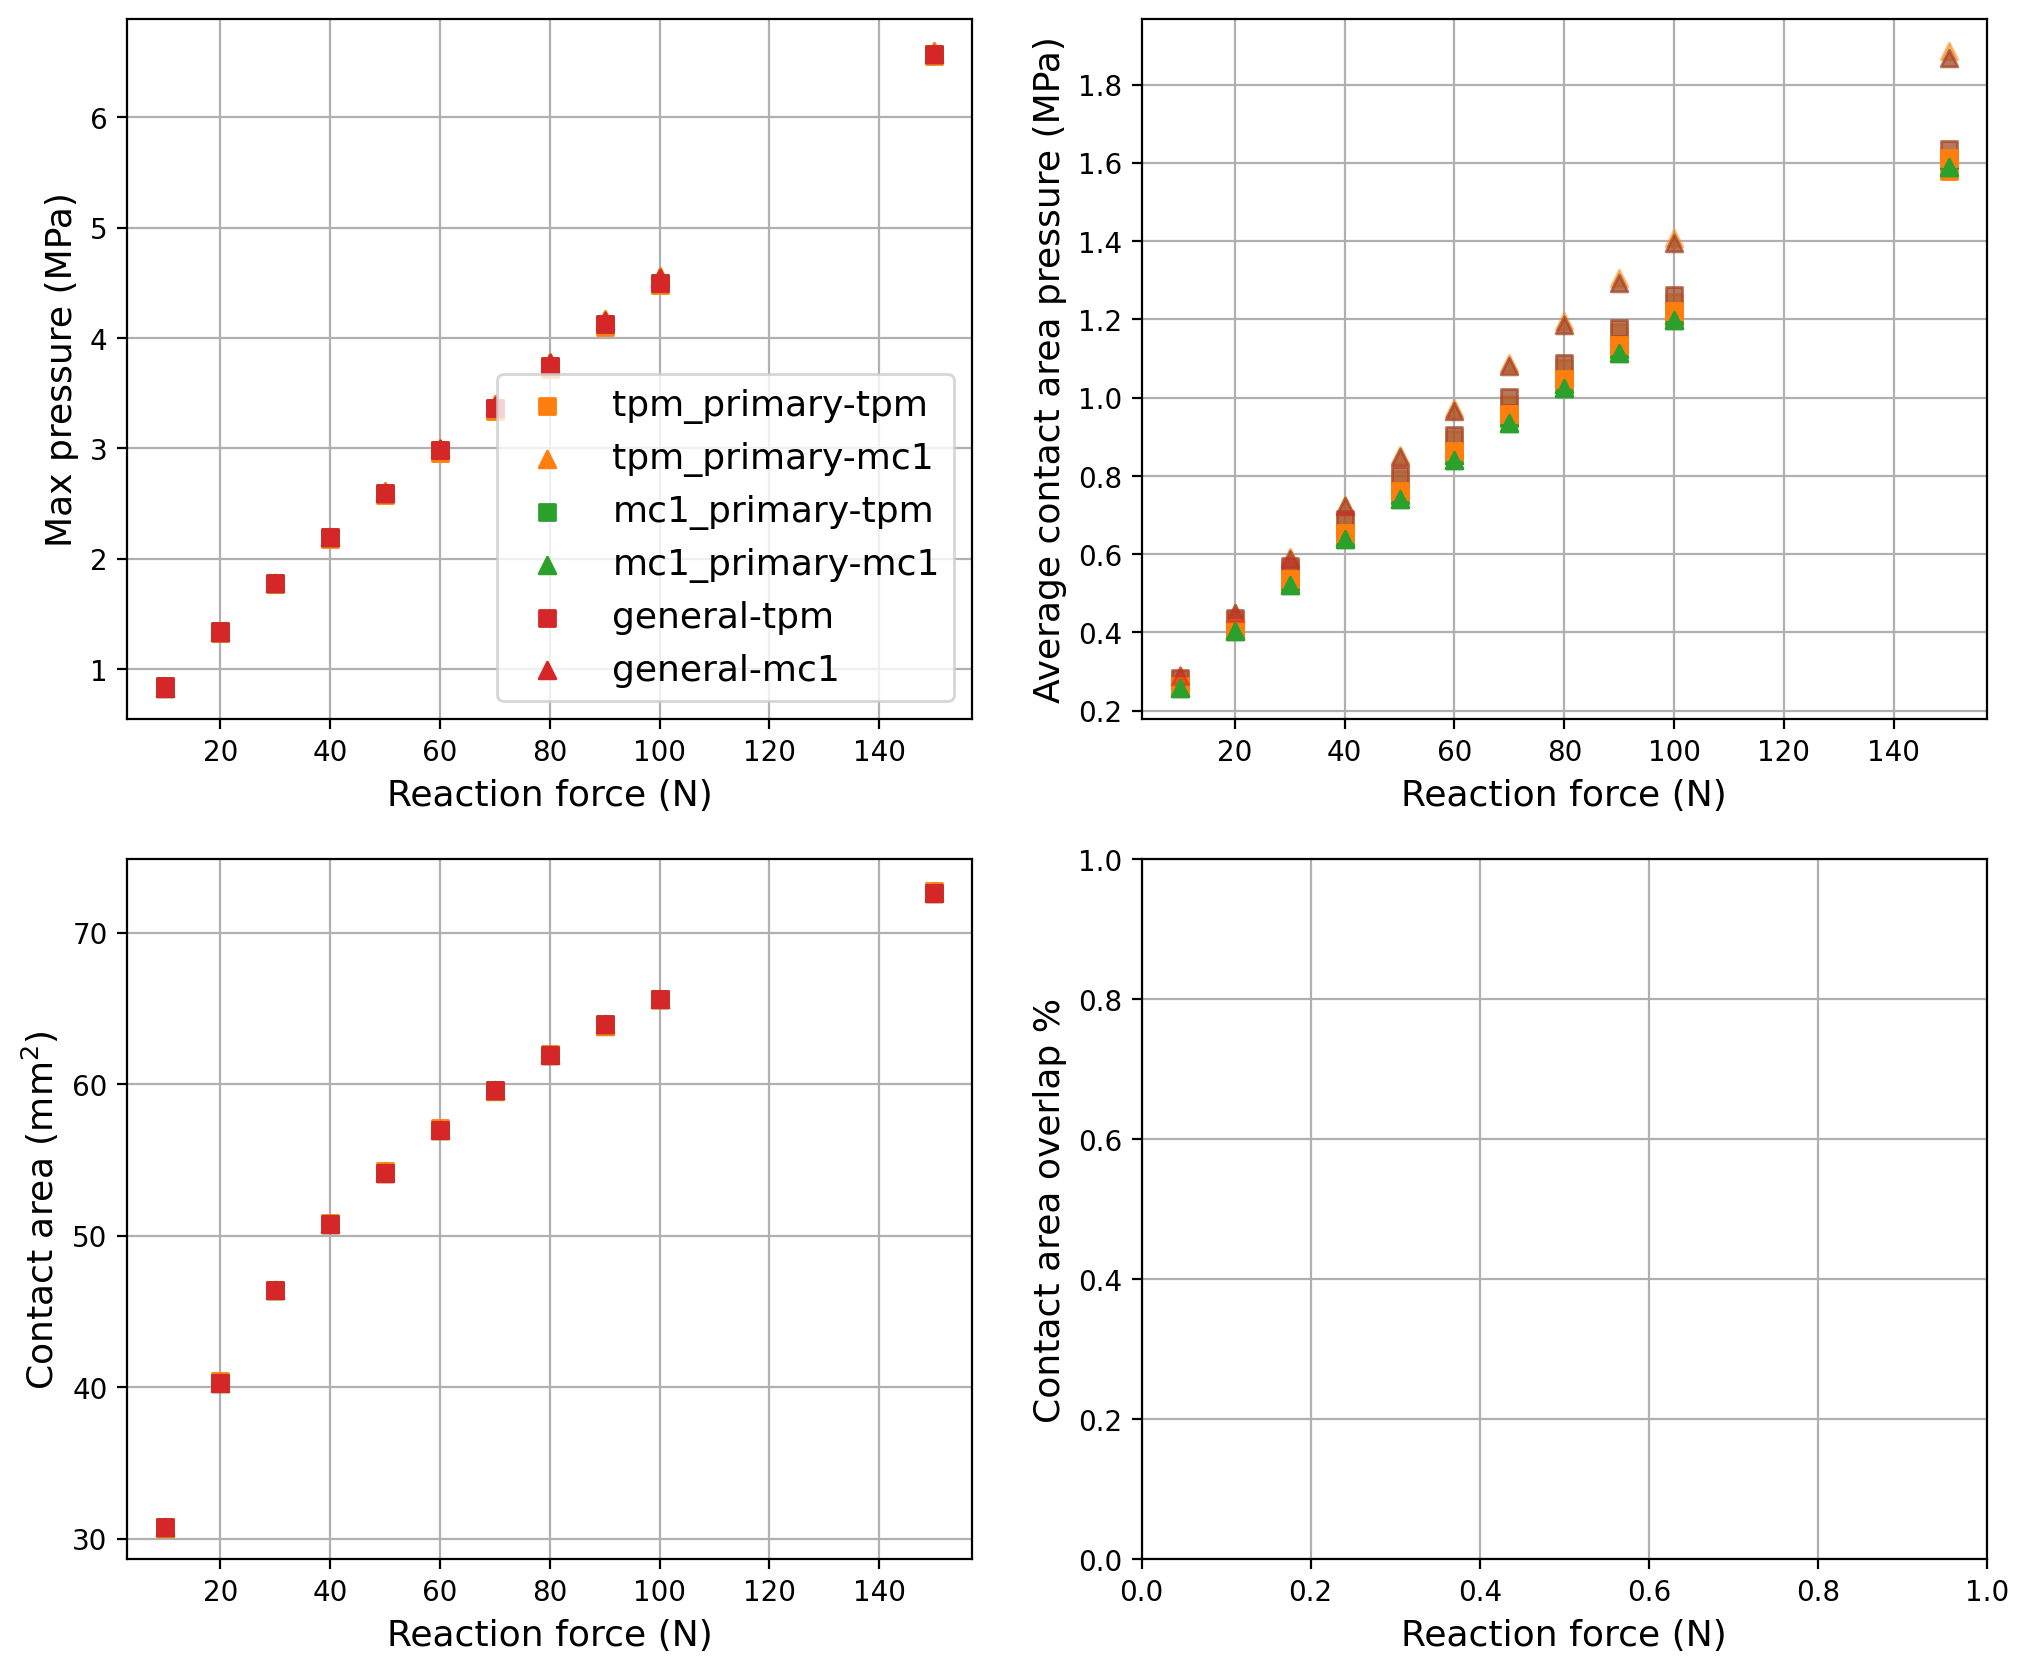

In [28]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)
ax = ax.flatten()


fs = 13

cs = ['C1', 'C2', 'C3']
ms = ['s', '^', 'o']
alphas = ['1.0', '0.5']

for i, fea_data in enumerate(fe_data):
    for j, bone in enumerate(['tpm', 'mc1']):
        for F in fea_data:
            fea_mets = fea_mets_from_mesh(fea_data[F][bone])

            label_fe = f'{names[i]}-{bone}' if F==10 else None
            ax[0].scatter(F, fea_mets['P_max'], c=cs[i], marker=ms[j], label=label_fe, zorder=2)
            ax[1].scatter(F, fea_mets['P_avg'], c=cs[i], marker=ms[j], zorder=2, alpha=0.5)
            ax[1].scatter(F, fea_mets['P_avg_weighted'], c=cs[j], marker=ms[j], zorder=2)
            ax[2].scatter(F, fea_mets['CA'], c=cs[i], marker=ms[j], zorder=2)



ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Average contact area pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
for ax_i in ax:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[0].legend(fontsize=fs)
#ax[3].legend(fontsize=fs)
plt.show()